In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import itertools

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from lmfit import Model
import qutip as qp
from typing import List
from pathlib import Path
import _pickle as cPickle
from tensor_networks_simulations.general_tools.plot_tools import figure_styling
figure_styling()


In [4]:
from lmfit.models import PolynomialModel
def polynomial(y_in: List, scale_list: List):
    model = PolynomialModel(2)
    params = model.guess(y_in, x=scale_list)
    #z = np.polyfit(scaling_list, y_in, (order-1))
    result = model.fit(data=y_in, params=params, x=scale_list)
    #print(result.fit_report())
    return result

In [5]:
#         for k in range(0, len(y)):
#             product = 1
#             for i in range(0, len(y)):
#                 if k != i:
#                     product = product * (scaling[i]/(scaling[k]-scaling[i]))
#             mitigated = mitigated + y[k]*product


def richardson(y_in: List, scale_list: List):    
    mitigated = 0
    for k in range(len(y_in)):
        product = 1
        for i in range(len(y_in)):
            if i != k:
                product = product * (scale_list[i]/(scale_list[i]-scale_list[k]))
        mitigated = mitigated + y_in[k]*product
    return mitigated

def polyexp():
    pass

In [6]:
from lmfit import Model

In [7]:
path=Path(os.getcwd()).parent
path = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_1st_set/")

In [8]:
model = "TFIChain"
dt = 0.005
t_f = 8
scale = 1
total_steps = int(t_f/(scale*dt))
L = 20
chi_max = 100
#cPickle_off = open(Path('data_L10_chi32')/f'mxs_{model}_L-{L}_chi-{chi_max}_scale-{1}_gamma-{0}.pickle', "rb")
cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_0 = dta
data_0

ts0 = 0.2*np.arange(0, len(dta))

len(dta), len(ts0)
print(ts0, dta)

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8 7.
 7.2 7.4 7.6 7.8 8. ] [1.0, 0.9618292861525652, 0.8546420417278031, 0.6987618099765557, 0.5229634514172304, 0.35814397335202924, 0.23074063426487262, 0.15743557039433867, 0.1424959823602093, 0.1779618547802411, 0.2466899748222704, 0.32718479014732293, 0.39891174042600896, 0.44675434181940094, 0.46363623695388345, 0.4508838932216618, 0.41650531865993756, 0.3721678411625628, 0.32959875993245974, 0.29789732182314405, 0.28158563932195285, 0.2805756714212231, 0.29116037202814393, 0.30787143974145426, 0.3254491051964516, 0.3402936539923045, 0.3510538025418513, 0.35832217123961346, 0.36370919835679144, 0.36875708015561737, 0.37442994224755394, 0.37958639179068193, 0.38199422019594476, 0.37971703527053857, 0.3703257484999188, 0.3522368621134345, 0.3262527126897692, 0.2962057352623945, 0.26650567887695825, 0.24187698030208749, 0.22725049471446462]


In [9]:
import random
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
print(get_colors(5))

markers = itertools.cycle(('o','s' ,'d', 'P', 'X', 'D', 'v', '<', '>', '^')) 

['#9db891', '#2914db', '#222317', '#2e9486', '#a719a5']


In [10]:
data = {}
#scale_list = [1.0, 1.25, 1.5, 1.75, 2]#, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
scale_list = [1.0, 0.25, 0.5, 0.75]#, 2.0, 2.5, 3.0, 3.5, 4.0]
gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]
#gamma_list = [0.001, 0.005, 0.01, 0.02, 0.05]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1, 0.25, 0.5]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]

len_gamma = len(gamma_list)
colors = get_colors(len_gamma)

In [11]:




yout_richadson_mx = {}
yout_richadson_mz = {}
mx_in = {}
mz_in = {}
ts = {}
data_richardson_mx = {}
data_richardson_mz = {}
tmp_data = {}
tss = {}

for i, gamma in enumerate(gamma_list):
    for scale in scale_list:
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mx_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mzs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mz_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        #print(len(mx_in[f"gamma={gamma}_scale={scale}"]), scale, gamma)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ts[f"ts_gamma{gamma}_scale{scale}"] = np.array(cPickle.load(cPickle_off))
        tss[f"ts_gamma{gamma}_scale{scale}"] = ts[f"ts_gamma{gamma}_scale{scale}"]/scale

        
#for scale in scale_list:    
for gamma in gamma_list:
        yout_richadson_mx[f"{gamma}"] = []
        yout_richadson_mz[f"{gamma}"] = []
        print(gamma)
        for i in range(len(tss[f"ts_gamma{gamma}_scale{1.0}"])):
            
            data_richardson_mx[f"gamma_{gamma}_{i}"] = [mx_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_mz[f"gamma_{gamma}_{i}"] = [mz_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            #print(data_richardson[f"gamma_{gamma}_{i}"], gamma)

            yout_richadson_mx[f"{gamma}"].append(richardson(data_richardson_mx[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_mz[f"{gamma}"].append(richardson(data_richardson_mz[f"gamma_{gamma}_{i}"], scale_list))
            #print(yout_richadson[f"{gamma}"][-1])


   
    
    
    


0.001
0.0025
0.005
0.0075
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.06
0.07
0.08
0.09
0.1


In [12]:
#fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))

18
3 6


/tmp/ipykernel_13432/1630505771.py:49: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


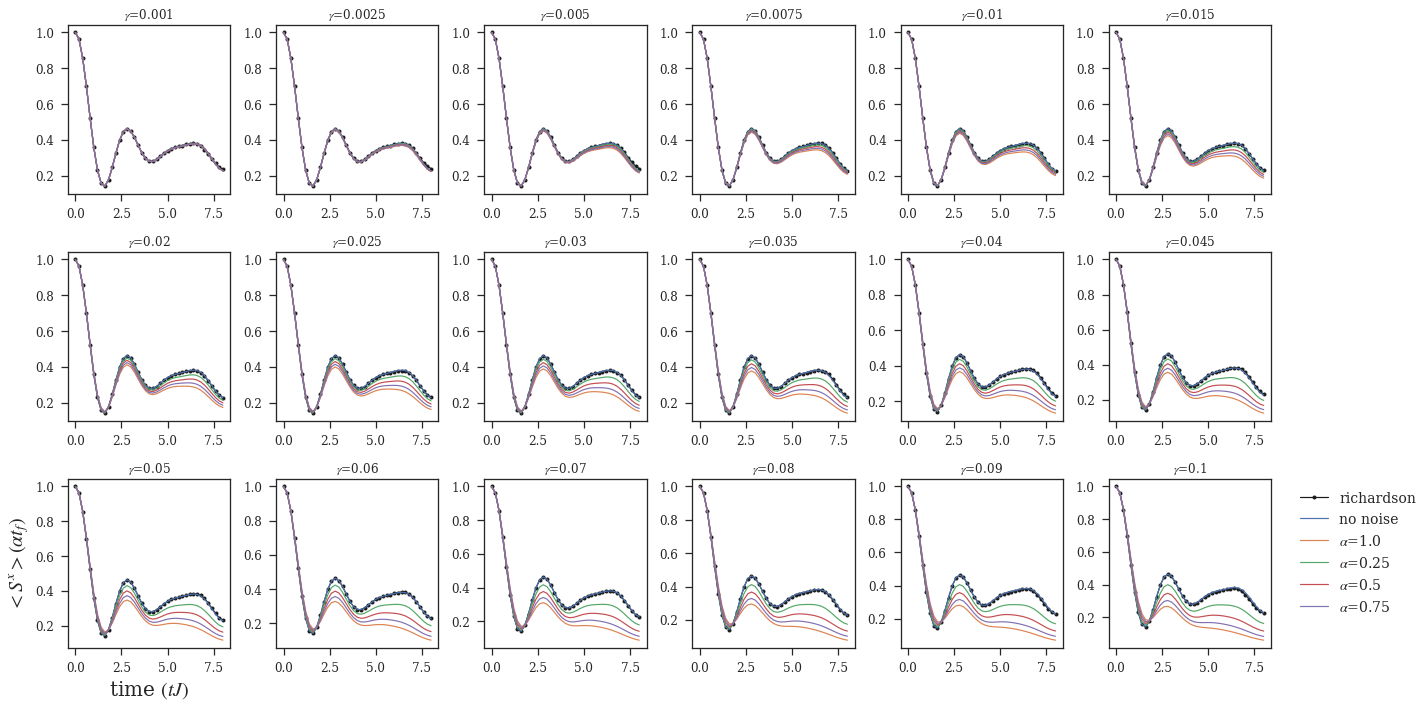

In [13]:
import seaborn as sns
sns.set_theme(style="ticks")

figure_styling()
data = {}
#scale_list = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
#gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
print(len(gamma_list))
nrows = 3
ncols = int(len(gamma_list)/nrows)#+1
print(nrows, ncols)

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20,10), constrained_layout=True)
m=0
for i, gamma in enumerate(gamma_list):
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            ax[m][n].plot(ts0, data_0, label="no noise")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', which='major', labelsize=12)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=8)
            
            g=False
        ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}")
        #ax[m][n].set_ylim(0.2,1)
        if n!=0:
            pass
            #ax[m][n].axes.yaxis.set_visible(False)
        if m != 2:
            #ax[m][n].axes.xaxis.set_visible(False)
            pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))

ax[2][0].set_xlabel(fr"time $(tJ)$", fontsize=20)
ax[2][0].set_ylabel(fr"$<S^x>(\alpha t_{{f}})$", fontsize=20)

plt.legend(bbox_to_anchor=[1.1, 1],ncol=1, frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(f"plot_{L}_chi_{chi_max}.pdf")

In [14]:
def jpp(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    print([[np.abs(a - i).argmin()] for i in b])
    return [b[np.abs(a - i).argmin()] for i in b]

def jpp2(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    print(np.argmin(np.abs(np.subtract.outer(a, b)), axis=0))
    return a[np.argmin(np.abs(np.subtract.outer(a, b)), axis=0)]

In [15]:
def lower_bound(sequence, value, compare):
    elements = len(sequence)
    offset = 0
    middle = 0
    found = len(sequence)

    while elements > 0:
        middle = elements >> 1
        if compare(value, sequence[offset + middle]) > 0:
            offset = offset + middle + 1
            elements = elements - (middle + 1)
        else:
            found = offset + middle
            elements = middle
    return found

In [16]:
# in_tss={}
# indices={}
# y_in_picked = {}

# for gamma in gamma_list:
#     for scale in scale_list:
#         #old_interval = [tss[f"ts_gamma{gamma}_scale{scale}"][0], tss[f"ts_gamma{gamma}_scale{scale}"][-1]]
#         #new_interavel = [0.0, 8.0]
#         #old_value = tss[f"ts_gamma{gamma}_scale{scale}"][-1]
#         #new_values = [np.interp(old_value, old_interval, new_interavel) for old_value in tss[f"ts_gamma{gamma}_scale{scale}"] ]
        
        
#         b = tss[f"ts_gamma{gamma}_scale{1}"]
#         a = tss[f"ts_gamma{gamma}_scale{scale}"]
#         re_a = a[::-1]

#         in_tss[f"ts_gamma{gamma}_scale{scale}"] = [min([a[lower_bound(a, i, lambda x,y: x > y) % len(a)], re_a[lower_bound(re_a, i, lambda x, y: x < y) % len(re_a)]], key=lambda num:abs(num-i)) for i in b]
#         aa = in_tss[f"ts_gamma{gamma}_scale{scale}"]
#         indices[f"ts_gamma{gamma}_scale{scale}"] = [list(a).index(i) for i in aa]
#         y_in_picked[f"gamma={gamma}_scale={scale}"] = [y_in[f"gamma={gamma}_scale={scale}"][i] for i in [list(a).index(i) for i in aa]]
        
        
#         #print(len(aa), indices[f"ts_gamma{gamma}_scale{scale}"])

In [17]:
# y_out_richadson = {}
# y_out_poly_eval = {}
# for gamma in gamma_list:
    
#     y_out_richadson[f"gamma_{gamma}"] = []
#     y_out_poly_eval[f"gamma_{gamma}"] = []
#     for i in range(len(in_tss[f"ts_gamma{gamma}_scale{scale}"])):
#         tmp_data_richardson = []
#         tmplist = []
#         scale_int = []
#         for scale in scale_list:
#             tmplist.append(y_in_picked[f"gamma={gamma}_scale={scale}"][i])
#             if np.mod(scale, 1) == 0:
#                 scale_int.append(scale)
#                 tmp_data_richardson.append(y_in_picked[f"gamma={gamma}_scale={scale}"][i])
        

#         y_out_richadson[f"gamma_{gamma}"].append(richardson(tmp_data_richardson, scale_int))
#         y_out_poly= polynomial(tmplist, scale_list)
    
#         print("richardson", y_in_picked[f"gamma={gamma}_scale={4.0}"][i],richardson(tmp_data_richardson, scale_int), in_tss[f"ts_gamma{gamma}_scale{scale}"][i],gamma)
#         #print("polynomial", y_out_poly.best_fit)
#         y_out_poly_eval[f"gamma_{gamma}"] = y_out_poly.eval(x=np.arange(-0.0, 5.01, 0.01), params=y_out_poly.params)
# #y_out_poly_eval

In [18]:
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
# for i, gamma in enumerate(gamma_list):
#     if gamma == 0.05:
#         print(y_out_richadson[f"gamma_{gamma}"])
#         ax.plot(in_tss[f"ts_gamma{gamma}_scale{scale}"], y_out_richadson[f"gamma_{gamma}"], color=colors[i],ls="-",lw=0.5,marker="o" ,ms=1, mfc="none",label=f"$\gamma={gamma}$")
#         for scale in scale_int:
#             #print(gamma, scale)
#             if scale==4:
#                 print("--------------------")
#                 print(y_in_picked[f"gamma={gamma}_scale={scale}"])
#             ax.plot(in_tss[f"ts_gamma{gamma}_scale{scale}"], y_in_picked[f"gamma={gamma}_scale={scale}"], "-" , label=fr"$\alpha$={scale}")

# ax.plot(ts0, data_0, color="k",lw= 2.5, label="free")           
# plt.legend(loc=(1.04,0),ncol=2, fontsize=15)

In [19]:
rich_list = {}
for j, gamma in enumerate(gamma_list):
    rich_list[f"gamma={gamma}"] = []
    for i, t in enumerate(tss[f"ts_gamma{gamma}_scale{1.0}"]):
    
        dta = np.array([mx_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_int ])
        rich = richardson(dta, scale_int)
        rich_list[f"gamma={gamma}"].append(rich)
        #print(dta, "-->",rich, gamma, t)
    #print("---------")

NameError: name 'scale_int' is not defined

In [ ]:
import seaborn as sns
sns.set_theme(style="ticks")

figure_styling()
data = {}
#scale_list = [1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
#gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
print(len(gamma_list))
nrows = 3
ncols = int(len(gamma_list)/nrows)#+1
print(nrows, ncols)

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20,10))
m=0
for i, gamma in enumerate(gamma_list):
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),rich_list[f"gamma={gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            ax[m][n].plot(ts0, data_0, label="no noise")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            
            
            g=False
        ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), marker = "o", ms=1, label=fr"$\alpha$={scale}")
        
        ax[m][n].set_title(fr"$\gamma$={gamma}")
        ax[m][n].set_ylim(0.2,1)
        if n!=0:
            
            ax[m][n].axes.yaxis.set_visible(False)
        if m != 2:
            ax[m][n].axes.xaxis.set_visible(False)

for i in range(6):
    ax[2][i].set_xticks(range(0,9,2))

ax[2][0].set_xlabel(fr"time $(tJ)$", fontsize=20)
ax[2][0].set_ylabel(fr"$<S^x>(\alpha t_{{f}})$", fontsize=20)

plt.legend(loc =(-7.15, 1.7),ncol=1, frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(f"plot_{L}_chi_{chi_max}.pdf")

In [ ]:
N_qubits = 4
for ii in range(0, N_qubits):
    nf_conf = np.array([int(i) for i in bin(ii)[2:].zfill(N_qubits)])
    
    print(bin(ii)[2:].zfill(N_qubits))
    nf_str = bin(ii)[2:].zfill(N_qubits)#" ".join(str(x) for x in nf_conf)
    print(nf_conf, nf_str, type(nf_str))

In [ ]:
final_time = 8
scale = 2.25 
dt = 0.005
total_steps = int(final_time/(scale*dt))
print(total_steps)
j = 0
for i in range(total_steps+1):
    if np.mod(i, int(20/scale)) ==0:
        j+=1
        #print(j, i, f"{scale*dt*(i+1):.4f}")

In [ ]:
path = Path("/home/younes/Documents/repos/tensor_networks_Hannover/Tensor_Networks_Simulations/jupyter-notebooks/data_cluster/")

In [ ]:
L = 32
chi_list = [100, 200]
scale =1.0
gamma = 0.005
dat={}
fig, ax = plt.subplots(nrows=1,ncols=1, figsize=(7,6))
for chi in chi_list:
    cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
    dta = cPickle.load(cPickle_off)
    cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
    tdta = cPickle.load(cPickle_off)
    print(len(dta), chi)
    ax.plot(tdta, dta, label=f"chi={chi}")
plt.legend()